# Monte Carlo Radiation Transport Demo

This notebook is written as a short teaching exercise. It uses two examples to explain the same Monte Carlo idea:

- estimate $\pi$ by random sampling,
- transport a particle through matter using a sampled mean free path,
- assign interaction outcomes using probabilities,
- and visualize how many random histories build a physical prediction.

The main message is simple: Monte Carlo methods use repeated random sampling to estimate quantities that are difficult to compute directly.

## 1. Warm-up: estimating $\pi$ with random points

A classic Monte Carlo example is the unit quarter-circle.

If we throw random points into the unit square $[0,1] \times [0,1]$, the fraction that fall inside the quarter-circle

$$
x^2 + y^2 \le 1
$$

is approximately

$$
\frac{\pi}{4}.
$$

So we can estimate $\pi$ from

$$
\pi \approx 4 \times \frac{\text{points inside the quarter-circle}}{\text{total number of points}}.
$$

In [1]:
# Import the libraries we need for numerical work and plotting.
import numpy as np
import matplotlib.pyplot as plt


# ---------- Monte Carlo warm-up: estimate pi ----------
def estimate_pi(num_points=5000, seed=7):
    """Estimate pi by random sampling in the unit square.

    We generate random points (x, y) in [0, 1] x [0, 1].
    Points with x^2 + y^2 <= 1 lie inside the quarter-circle.
    The fraction inside is approximately pi / 4.
    """
    rng = np.random.default_rng(seed)
    x = rng.random(num_points)
    y = rng.random(num_points)

    # Boolean mask: True for points inside the quarter-circle.
    inside = x**2 + y**2 <= 1.0

    # Monte Carlo estimate of pi.
    pi_estimate = 4.0 * inside.mean()
    return x, y, inside, pi_estimate




In [2]:
x, y, inside, pi_estimate = estimate_pi(num_points=4000, seed=12)
print(f"Monte Carlo estimate of pi: {pi_estimate:.5f}")
print(f"Reference value of pi:      {np.pi:.5f}")


Monte Carlo estimate of pi: 3.12100
Reference value of pi:      3.14159


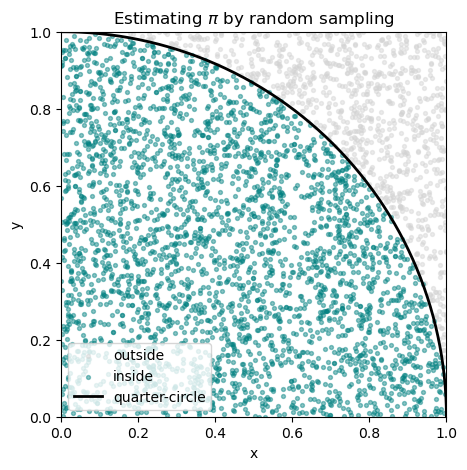

In [3]:


# Plot the random points to show where the estimate comes from.
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x[~inside], y[~inside], s=8, alpha=0.45, color="lightgray", label="outside")
ax.scatter(x[inside], y[inside], s=8, alpha=0.45, color="teal", label="inside")

theta = np.linspace(0, np.pi / 2, 300)
ax.plot(np.cos(theta), np.sin(theta), color="black", linewidth=2, label="quarter-circle")
ax.set_aspect("equal")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Estimating $\\pi$ by random sampling")
ax.legend(loc="lower left")
plt.show()

## 2. From $\pi$ to radiation transport

The same Monte Carlo pattern appears in radiation transport:

1. draw a random number,
2. convert it into a physical quantity,
3. update the particle state,
4. repeat until the particle is absorbed or escapes.

For transport, the random sampling is used for quantities such as:

- the distance to the next interaction,
- the type of interaction that occurs,
- and sometimes the direction or energy after scattering.

So the $\pi$ problem is the simplest possible Monte Carlo example, while radiation transport is a richer physical version of the same idea.

## 3. Two-minute transport quiz

Now we move to a simple slab detector extending from $x=0$ to $x=10$ cm.

We will use two pieces of physics:

- **Mean free path** $\lambda = 2$ cm
- **Interaction probabilities**
  - $P(\text{scatter}) = 0.7$
  - $P(\text{absorb}) = 0.3$

For a uniform random number $u$ in $(0,1)$, the distance to the next interaction is sampled from the exponential law

$$
s = -\lambda \ln(1-u).
$$

**Quiz:** use the fixed random numbers below.

- Free-path random numbers: `[0.20, 0.55, 0.80]`
- Interaction random numbers: `[0.40, 0.85, 0.10]`

Questions:
1. What is the first sampled free path?
2. Is the first interaction scatter or absorb?
3. After the second sampled free path, is the particle still inside the slab?
4. What is the final outcome?

In [4]:
# ---------- Monte Carlo transport model ----------

# Detector thickness in centimeters.
SLAB_THICKNESS = 10.0

# Physics parameters for our toy transport model.
MEAN_FREE_PATH = 2.0
P_SCATTER = 0.7
P_ABSORB = 0.3

In [5]:


def sample_free_path(random_value, mean_free_path=MEAN_FREE_PATH):
    """Convert a uniform random number into an exponentially distributed free path.

    In radiation transport, the distance between interactions is often sampled
    from an exponential distribution with mean value lambda.
    """
    return -mean_free_path * np.log(1.0 - random_value)


In [6]:


def sample_interaction(random_value, p_scatter=P_SCATTER):
    """Choose scatter or absorb based on a probability threshold."""
    return "scatter" if random_value < p_scatter else "absorb"

In [7]:


def transport_particle(distance_randoms, interaction_randoms, slab_thickness=SLAB_THICKNESS):
    """Transport one particle through a 1D slab.

    The particle starts at x = 0 cm and moves in the +x direction.
    At each interaction site we sample:
    1. a free path,
    2. an interaction type.

    The history ends when the particle escapes or is absorbed.
    """
    position = 0.0
    x_positions = [position]
    y_positions = [0.0]
    events = []

    for step_index, (distance_rn, interaction_rn) in enumerate(zip(distance_randoms, interaction_randoms), start=1):
        # Sample how far the particle travels before the next interaction.
        free_path = sample_free_path(distance_rn)
        new_position = position + free_path

        # If the sampled interaction point lies beyond the slab, the particle escapes.
        if new_position >= slab_thickness:
            x_positions.append(slab_thickness)
            y_positions.append(0.0)
            events.append({
                "step": step_index,
                "distance_rn": distance_rn,
                "free_path": free_path,
                "position": slab_thickness,
                "interaction_rn": None,
                "interaction": "escape",
            })
            return {
                "outcome": "escaped",
                "events": events,
                "x_positions": x_positions,
                "y_positions": y_positions,
            }

        # Otherwise the particle really interacts inside the material.
        position = new_position
        x_positions.append(position)
        y_positions.append(0.0)

        interaction = sample_interaction(interaction_rn)
        events.append({
            "step": step_index,
            "distance_rn": distance_rn,
            "free_path": free_path,
            "position": position,
            "interaction_rn": interaction_rn,
            "interaction": interaction,
        })

        if interaction == "absorb":
            return {
                "outcome": "absorbed",
                "events": events,
                "x_positions": x_positions,
                "y_positions": y_positions,
            }

    return {
        "outcome": "still alive after provided random numbers",
        "events": events,
        "x_positions": x_positions,
        "y_positions": y_positions,
    }


In [14]:


def print_history_summary(history):
    """Print a readable summary of one particle history."""
    for event in history["events"]:
        if event["interaction"] == "escape":
            print(
                f"Step {event['step']}: distance RN={event['distance_rn']:.2f}, "
                f"free path={event['free_path']:.2f} cm -> particle escapes at x={event['position']:.2f} cm"
            )
        else:
            print(
                f"Step {event['step']}: distance RN={event['distance_rn']:.2f}, "
                f"free path={event['free_path']:.2f} cm -> x={event['position']:.2f} cm, "
                f"interaction RN={event['interaction_rn']:.2f}, {event['interaction']}"
            )
    print(f"Final outcome: {history['outcome']}")

In [9]:
# ---------- Monte Carlo transport model ----------

# Detector thickness in centimeters.
SLAB_THICKNESS = 10.0

# Physics parameters for our toy transport model.
MEAN_FREE_PATH = 2.0
P_SCATTER = 0.7
P_ABSORB = 0.3






In [10]:
# Fixed random numbers for the classroom quiz.
const_distance_randoms = [0.20, 0.55, 0.80]
const_interaction_randoms = [0.40, 0.85, 0.10]

const_history = transport_particle(const_distance_randoms, const_interaction_randoms)
print_history_summary(const_history)

Step 1: distance RN=0.20, free path=0.45 cm -> x=0.45 cm, interaction RN=0.40, scatter
Step 2: distance RN=0.55, free path=1.60 cm -> x=2.04 cm, interaction RN=0.85, absorb
Final outcome: absorbed


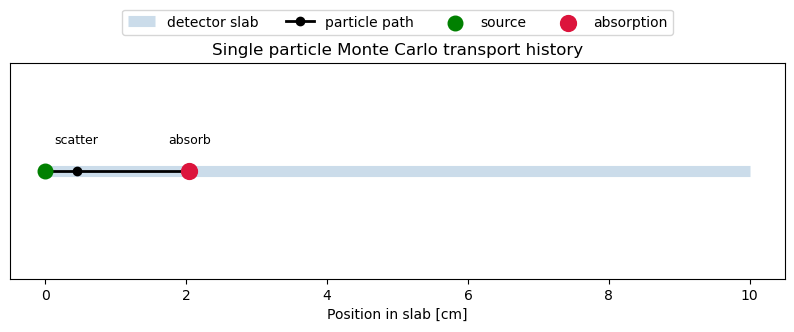

In [11]:
# Plot one particle history so the propagation is easy to see.
fig, ax = plt.subplots(figsize=(10, 2.8))

# Draw the detector slab as a thick horizontal band.
ax.hlines(0, 0, SLAB_THICKNESS, color="steelblue", linewidth=8, alpha=0.28, label="detector slab")

# Draw the particle path from one interaction site to the next.
ax.plot(
    const_history["x_positions"],
    const_history["y_positions"],
    marker="o",
    color="black",
    linewidth=2,
    label="particle path",
)

# Mark the source position.
ax.scatter([0], [0], color="green", s=110, zorder=3, label="source")

# Highlight the final state.
final_x = const_history["x_positions"][-1]
if const_history["outcome"] == "absorbed":
    ax.scatter([final_x], [0], color="crimson", s=130, zorder=4, label="absorption")
else:
    ax.scatter([final_x], [0], color="darkorange", s=130, zorder=4, label="escape")

# Label each interaction so students can connect the plot to the history summary.
for event in const_history["events"]:
    ax.text(event["position"], 0.14, event["interaction"], ha="center", fontsize=9)

ax.set_xlim(-0.5, SLAB_THICKNESS + 0.5)
ax.set_ylim(-0.55, 0.55)
ax.set_xlabel("Position in slab [cm]")
ax.set_yticks([])
ax.set_title("Single particle Monte Carlo transport history")
ax.legend(loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.28))
plt.show()

## 4. Many particle histories

A single history is interesting, but Monte Carlo becomes powerful when we repeat the same sampling procedure many times.

By simulating many particles, we can estimate quantities such as:

- the fraction absorbed in the detector,
- the fraction that escape,
- and the distribution of interaction locations.

This is exactly the same idea as the $\pi$ example: one trial is noisy, but many trials reveal a stable estimate.

In [12]:
def simulate_random_history(rng, max_steps=25, slab_thickness=SLAB_THICKNESS):
    """Generate one random particle history using the transport model."""
    distance_randoms = rng.random(max_steps)
    interaction_randoms = rng.random(max_steps)
    return transport_particle(distance_randoms, interaction_randoms, slab_thickness=slab_thickness)


rng = np.random.default_rng(42)
histories = [simulate_random_history(rng) for _ in range(12)]

absorbed_count = sum(history["outcome"] == "absorbed" for history in histories)
escaped_count = sum(history["outcome"] == "escaped" for history in histories)

print(f"Absorbed: {absorbed_count}")
print(f"Escaped:  {escaped_count}")
print(f"Estimated absorption fraction: {absorbed_count / len(histories):.2f}")

Absorbed: 9
Escaped:  3
Estimated absorption fraction: 0.75


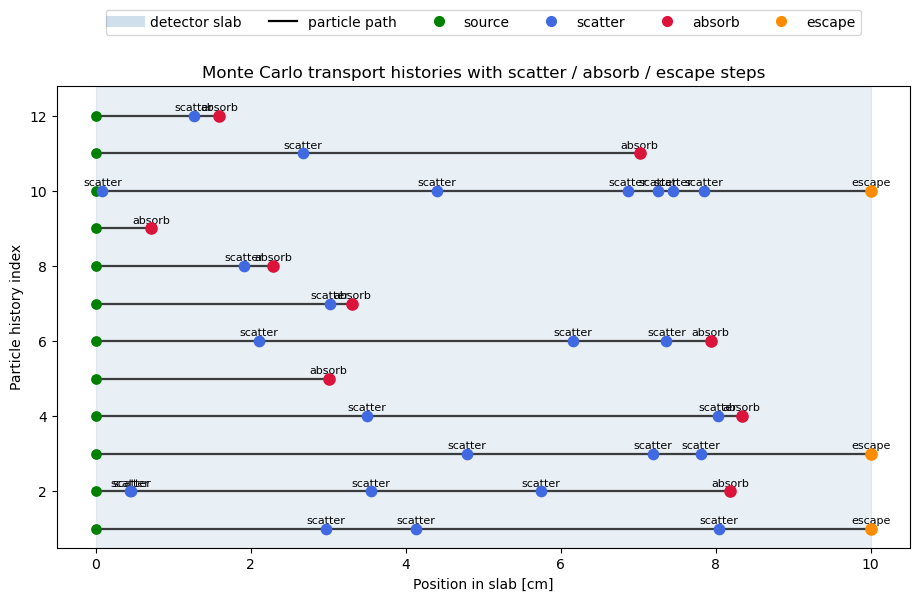

In [15]:
# Plot many particle histories, but show individual interaction types.
fig, ax = plt.subplots(figsize=(11, 6))
ax.axvspan(0, SLAB_THICKNESS, color="steelblue", alpha=0.12, label="detector slab")

for row, history in enumerate(histories, start=1):
    y = row

    # Draw the full particle path on one horizontal row.
    x_positions = history["x_positions"]
    y_positions = np.full(len(x_positions), y)
    ax.plot(
        x_positions,
        y_positions,
        color="black",
        linewidth=1.6,
        alpha=0.75,
    )

    # Mark the source for this history.
    ax.scatter([0], [y], color="green", s=45, zorder=3)

    # Mark each interaction or escape event individually.
    for event in history["events"]:
        x_event = event["position"]

        if event["interaction"] == "scatter":
            ax.scatter([x_event], [y], color="royalblue", s=55, zorder=4)
            ax.text(x_event, y + 0.14, "scatter", ha="center", fontsize=8)

        elif event["interaction"] == "absorb":
            ax.scatter([x_event], [y], color="crimson", s=65, zorder=5)
            ax.text(x_event, y + 0.14, "absorb", ha="center", fontsize=8)

        elif event["interaction"] == "escape":
            ax.scatter([x_event], [y], color="darkorange", s=65, zorder=5)
            ax.text(x_event, y + 0.14, "escape", ha="center", fontsize=8)

ax.set_xlim(-0.5, SLAB_THICKNESS + 0.5)
ax.set_ylim(0.5, len(histories) + 0.8)
ax.set_xlabel("Position in slab [cm]")
ax.set_ylabel("Particle history index")
ax.set_title("Monte Carlo transport histories with scatter / absorb / escape steps")

# Build a clean legend manually.
from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color="steelblue", linewidth=8, alpha=0.25, label="detector slab"),
    Line2D([0], [0], color="black", linewidth=1.6, label="particle path"),
    Line2D([0], [0], marker="o", color="green", linestyle="None", markersize=7, label="source"),
    Line2D([0], [0], marker="o", color="royalblue", linestyle="None", markersize=7, label="scatter"),
    Line2D([0], [0], marker="o", color="crimson", linestyle="None", markersize=7, label="absorb"),
    Line2D([0], [0], marker="o", color="darkorange", linestyle="None", markersize=7, label="escape"),
]
ax.legend(handles=legend_handles, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.18))

plt.show()